# Books Scrape

In [74]:
# Import required libraries
import pandas as pd
import numpy as np
import re
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin

import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
# Set the website URL

url = "https://books.toscrape.com/index.html"

In [76]:
# Set browser headers for the request

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/151.0.0.0 Safari/537.36",
    "Accept-Language": "en-IN,en;q=0.9"
}

In [77]:
# Send request to the website

response = requests.get(
    url,
    headers=headers,
    timeout=30
)

# Check the response status
print(response.status_code)

200


In [78]:
# See the contents of the page
response.content

b'<!DOCTYPE html>\n<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->\n<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->\n<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->\n<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->\n    <head>\n        <title>\n    All products | Books to Scrape - Sandbox\n</title>\n\n        <meta http-equiv="content-type" content="text/html; charset=UTF-8" />\n        <meta name="created" content="24th Jun 2016 09:29" />\n        <meta name="description" content="" />\n        <meta name="viewport" content="width=device-width" />\n        <meta name="robots" content="NOARCHIVE,NOCACHE" />\n\n        <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->\n        <!--[if lt IE 9]>\n        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>\n        <![endif]-->\n\n        \n            <link rel="shortcut icon" hre

In [80]:
# Create an empty list to store book details
empty_list = []

In [81]:
# Create an empty list

empty_list = []


# Scrape pages 1 to 29

for page in range(1, 30):

    page_url = f"https://books.toscrape.com/catalogue/page-{page}.html"

    try:

        response = requests.get(
            page_url,
            headers=headers,
            timeout=30
        )

        response.raise_for_status()

        bs = BeautifulSoup(response.text, "html.parser")

        # Find all books

        Book_container = bs.select("article.product_pod")

        for Book in Book_container:

            # Get title

            title_tag = Book.select_one("h3 a")

            if not title_tag:
                continue

            title = title_tag.get_text(" ", strip=True)

            # Get price

            price_tag = Book.select_one("p.price_color")

            # Get rating

            rating_tag = Book.select_one("p.star-rating")

            # Get availability

            availible_tag = Book.select_one(
                "p.instock.availability"
            )

            # Category

            category = "N/A"

            # Store book information

            empty_list.append({
                "title": title,
                "rating_tag": rating_tag.get("class")[1]
                if rating_tag else "N/A",

                "price_tag": price_tag.get_text(strip=True)
                if price_tag else "N/A",

                "availible_tag": availible_tag.get_text(
                    " ", strip=True
                ) if availible_tag else "N/A",

                "category": category
            })

        print("Page", page, "completed")

    except requests.exceptions.RequestException as e:

        print("Page", page, "failed:", e)


# Display number of books

print("Total books:", len(empty_list))

Page 1 completed
Page 2 completed
Page 3 completed
Page 4 completed
Page 5 completed
Page 6 completed
Page 7 completed
Page 8 completed
Page 9 completed
Page 10 completed
Page 11 completed
Page 12 completed
Page 13 completed
Page 14 completed
Page 15 completed
Page 16 completed
Page 17 completed
Page 18 completed
Page 19 completed
Page 20 completed
Page 21 completed
Page 22 completed
Page 23 completed
Page 24 completed
Page 25 completed
Page 26 completed
Page 27 completed
Page 28 completed
Page 29 completed
Total books: 580


In [89]:
# Display first 5 scraped books

for item in empty_list[:5]:

    print("Title:", item["title"])
    print("Rating:", item["rating_tag"])
    print("Availability:", item["availible_tag"])
    print("Price:", item["price_tag"])
    print("Category:", item["category"])

    print("-" * 50)

Title: A Light in the ...
Rating: Three
Availability: In stock
Price: Â£51.77
Category: N/A
--------------------------------------------------
Title: Tipping the Velvet
Rating: One
Availability: In stock
Price: Â£53.74
Category: N/A
--------------------------------------------------
Title: Soumission
Rating: One
Availability: In stock
Price: Â£50.10
Category: N/A
--------------------------------------------------
Title: Sharp Objects
Rating: Four
Availability: In stock
Price: Â£47.82
Category: N/A
--------------------------------------------------
Title: Sapiens: A Brief History ...
Rating: Five
Availability: In stock
Price: Â£54.23
Category: N/A
--------------------------------------------------


In [90]:
# Convert scraped data into DataFrame

df = pd.DataFrame(empty_list)

# Display first 5 rows
df.head()

,title,rating_tag,price_tag,availible_tag,category
0,A Light in the ...,Three,Â£51.77,In stock,N/A
1,Tipping the Velvet,One,Â£53.74,In stock,N/A
2,Soumission,One,Â£50.10,In stock,N/A
3,Sharp Objects,Four,Â£47.82,In stock,N/A
4,Sapiens: A Brief History ...,Five,Â£54.23,In stock,N/A


In [91]:
# Check dataset shape
print("Shape:", df.shape)

# Check column names
print("Columns:")
print(df.columns)

Shape: (580, 5)
Columns:
Index(['title', 'rating_tag', 'price_tag', 'availible_tag', 'category'], dtype='object')


In [92]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 580 entries, 0 to 579
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          580 non-null    object
 1   rating_tag     580 non-null    object
 2   price_tag      580 non-null    object
 3   availible_tag  580 non-null    object
 4   category       580 non-null    object
dtypes: object(5)
memory usage: 22.8+ KB


In [93]:
# Check missing values
df.isnull().sum()

title            0
rating_tag       0
price_tag        0
availible_tag    0
category         0
dtype: int64

In [94]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [95]:
# Save raw dataset
df.to_csv("Books_Scraped_Raw_Dataset.csv", index=False)

print("Raw dataset saved successfully.")

Raw dataset saved successfully.


# Data Cleaning

In [96]:
# Create a copy for data cleaning

books_df = df.copy()

# Display the data
books_df.head()

,title,rating_tag,price_tag,availible_tag,category
0,A Light in the ...,Three,Â£51.77,In stock,N/A
1,Tipping the Velvet,One,Â£53.74,In stock,N/A
2,Soumission,One,Â£50.10,In stock,N/A
3,Sharp Objects,Four,Â£47.82,In stock,N/A
4,Sapiens: A Brief History ...,Five,Â£54.23,In stock,N/A


In [97]:
# Rename columns with simple names

books_df.columns = [
    "Title",
    "Rating",
    "Price",
    "Availability",
    "Category"
]

books_df.head()

,Title,Rating,Price,Availability,Category
0,A Light in the ...,Three,Â£51.77,In stock,N/A
1,Tipping the Velvet,One,Â£53.74,In stock,N/A
2,Soumission,One,Â£50.10,In stock,N/A
3,Sharp Objects,Four,Â£47.82,In stock,N/A
4,Sapiens: A Brief History ...,Five,Â£54.23,In stock,N/A


In [101]:
# Remove currency symbols and convert price to number

books_df["Price"] = (
    books_df["Price"]
    .astype(str)
    .str.replace("£", "", regex=False)
    .str.replace("Â", "", regex=False)
    .str.strip()
)

books_df["Price"] = pd.to_numeric(
    books_df["Price"],
    errors="coerce"
)

books_df["Price"].head()

0    51.77
1    53.74
2    50.10
3    47.82
4    54.23
Name: Price, dtype: float64

In [102]:
# Convert rating words into numbers

rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

books_df["Rating"] = books_df["Rating"].map(rating_map)

books_df["Rating"].head()

0    3
1    1
2    1
3    4
4    5
Name: Rating, dtype: int64

In [104]:
# Remove extra spaces from book titles

books_df["Title"] = books_df["Title"].str.strip()

In [105]:
# Remove duplicate book titles

books_df = books_df.drop_duplicates(
    subset="Title"
)

print("Dataset shape:", books_df.shape)

Dataset shape: (579, 6)


In [106]:
# Remove rows with missing important values

books_df = books_df.dropna(
    subset=["Title", "Price", "Rating", "Category"]
)

print("Missing values:")
print(books_df.isnull().sum())

Missing values:
Title           0
Rating          0
Price           0
Availability    0
Category        0
Stock           0
dtype: int64


In [107]:
print(books_df.columns)

Index(['Title', 'Rating', 'Price', 'Availability', 'Category', 'Stock'], dtype='object')


# Feature Engineering

In [127]:
# Create price range categories

price = books_df.loc[:, "Price"]

# If Price appears more than once, take the first Price column
if len(price.shape) > 1:
    price = price.iloc[:, 0]

price = pd.to_numeric(
    price.astype(str)
         .str.replace("£", "", regex=False)
         .str.replace("Â", "", regex=False)
         .str.strip(),
    errors="coerce"
)

books_df["Price_Range"] = pd.cut(
    price,
    bins=[0, 20, 40, 60, 100],
    labels=["Low", "Medium", "High", "Very High"]
)

books_df[["Price_Range"]].head()

,Price_Range
0,High
1,High
2,High
3,High
4,High


In [128]:
# Create stock availability categories

books_df["Stock_Status"] = books_df["Stock"].apply(
    lambda x: "Available" if x > 0 else "Out of Stock"
)

books_df[["Stock", "Stock_Status"]].head()

,Stock,Stock_Status
0,0,Out of Stock
1,0,Out of Stock
2,0,Out of Stock
3,0,Out of Stock
4,0,Out of Stock


In [129]:
# Display the cleaned dataset

books_df.head()

,Title,Rating,Price,Availability,Category,Price,Stock,Price_Range,Stock_Status
0,A Light in the ...,3,Â£51.77,In stock,N/A,51.77,0,High,Out of Stock
1,Tipping the Velvet,1,Â£53.74,In stock,N/A,53.74,0,High,Out of Stock
2,Soumission,1,Â£50.10,In stock,N/A,50.10,0,High,Out of Stock
3,Sharp Objects,4,Â£47.82,In stock,N/A,47.82,0,High,Out of Stock
4,Sapiens: A Brief History ...,5,Â£54.23,In stock,N/A,54.23,0,High,Out of Stock


In [130]:
# Check the final dataset

print("Final Shape:", books_df.shape)

books_df.info()

Final Shape: (580, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 580 entries, 0 to 579
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Title         580 non-null    object  
 1   Rating        580 non-null    int64   
 2   Price         580 non-null    object  
 3   Availability  580 non-null    object  
 4   Category      580 non-null    object  
 5   Price         580 non-null    float64 
 6   Stock         580 non-null    int32   
 7   Price_Range   580 non-null    category
 8   Stock_Status  580 non-null    object  
dtypes: category(1), float64(1), int32(1), int64(1), object(5)
memory usage: 34.9+ KB


In [131]:
# Create DataFrame from scraped book data

books_df = pd.DataFrame(empty_list)

print("Dataset shape:", books_df.shape)
books_df.head()

Dataset shape: (580, 5)


,title,rating_tag,price_tag,availible_tag,category
0,A Light in the ...,Three,Â£51.77,In stock,N/A
1,Tipping the Velvet,One,Â£53.74,In stock,N/A
2,Soumission,One,Â£50.10,In stock,N/A
3,Sharp Objects,Four,Â£47.82,In stock,N/A
4,Sapiens: A Brief History ...,Five,Â£54.23,In stock,N/A


In [132]:
# Save the cleaned dataset

books_df.to_csv(
    "Books_Cleaned_dataset.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [133]:
# Clean price values

books_df["Price"] = (
    books_df["price_tag"]
    .str.replace("£", "", regex=False)
    .str.replace("Â", "", regex=False)
    .str.strip()
    .astype(float)
)

print(books_df["Price"].head())

0    51.77
1    53.74
2    50.10
3    47.82
4    54.23
Name: Price, dtype: float64


In [134]:
# Clean stock values

books_df["Stock"] = pd.to_numeric(
    books_df["availible_tag"].str.extract(r"(\d+)")[0],
    errors="coerce"
).fillna(0).astype(int)

In [135]:
# Check stock values

print(books_df["Stock"].head())

0    0
1    0
2    0
3    0
4    0
Name: Stock, dtype: int32


In [136]:
# Clean stock values

stock = books_df["availible_tag"].str.extract(r"(\d+)")[0]

books_df["Stock"] = pd.to_numeric(stock, errors="coerce")
books_df["Stock"] = books_df["Stock"].fillna(0).astype(int)

print(books_df["Stock"].head())

0    0
1    0
2    0
3    0
4    0
Name: Stock, dtype: int32


In [138]:
# Convert rating words into numbers

rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

books_df["Rating"] = books_df["Rating"].map(rating_map)

print(books_df["Rating"].value_counts().sort_index())

Rating
1    122
2    116
3    116
4    114
5    112
Name: count, dtype: int64


In [139]:
# Check the cleaned dataset

print("Final dataset shape:", books_df.shape)
books_df.head()

Final dataset shape: (580, 7)


,Title,Rating,Price,Availability,Category,Price,Stock
0,A Light in the ...,3,Â£51.77,In stock,N/A,51.77,0
1,Tipping the Velvet,1,Â£53.74,In stock,N/A,53.74,0
2,Soumission,1,Â£50.10,In stock,N/A,50.10,0
3,Sharp Objects,4,Â£47.82,In stock,N/A,47.82,0
4,Sapiens: A Brief History ...,5,Â£54.23,In stock,N/A,54.23,0


# Data Visualizations

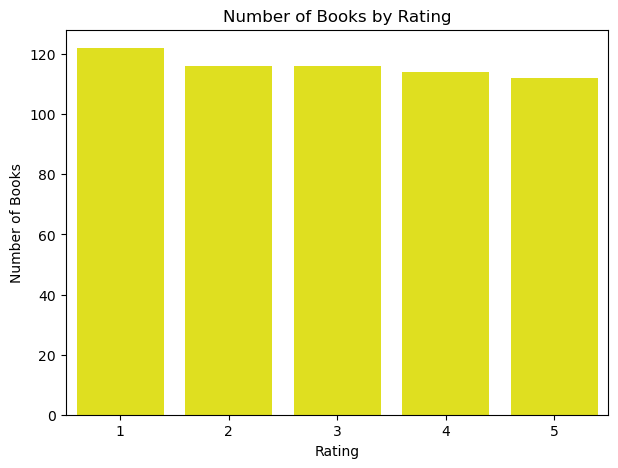

In [147]:
# Number of books by rating

plt.figure(figsize=(7, 5))

sns.countplot(data=books_df, x="Rating", color='Yellow')

plt.title("Number of Books by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.show()

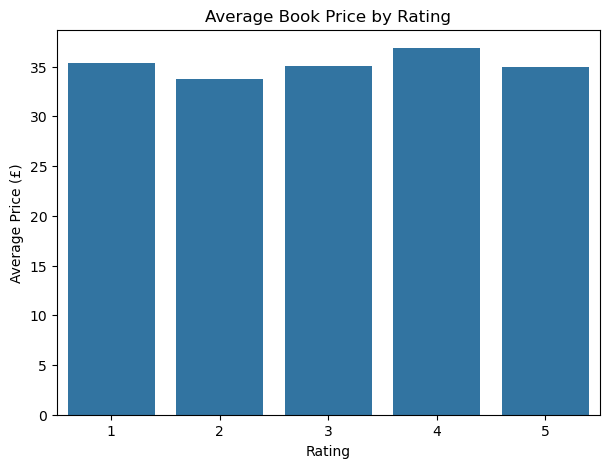

In [165]:
# 2. Average price by rating

avg_price = books_df.groupby("Rating")["Price"].mean().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(data=avg_price, x="Rating", y="Price")

plt.title("Average Book Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price (£)")

plt.show()

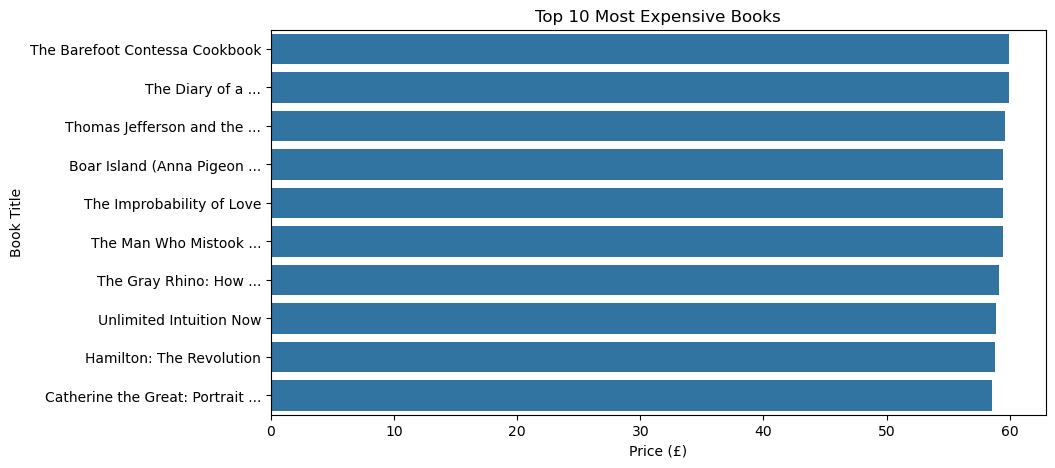

In [166]:
# 3. Top 10 most expensive books

top_books = books_df.sort_values(
    "Price",
    ascending=False
).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_books,
    x="Price",
    y="Title"
)

plt.title("Top 10 Most Expensive Books")
plt.xlabel("Price (£)")
plt.ylabel("Book Title")

plt.show()

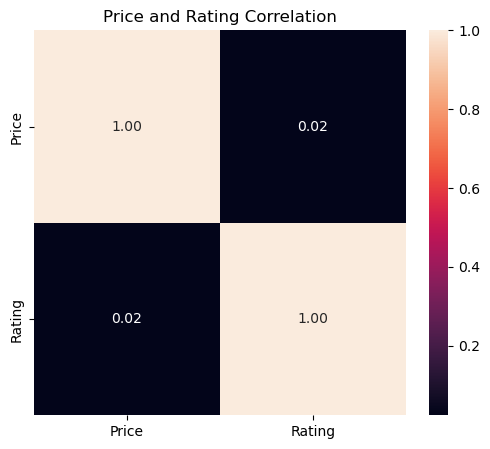

In [167]:
# 10. Correlation between price and rating

correlation = books_df[
    ["Price", "Rating"]
].corr()

plt.figure(figsize=(6, 5))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Price and Rating Correlation")

plt.show()

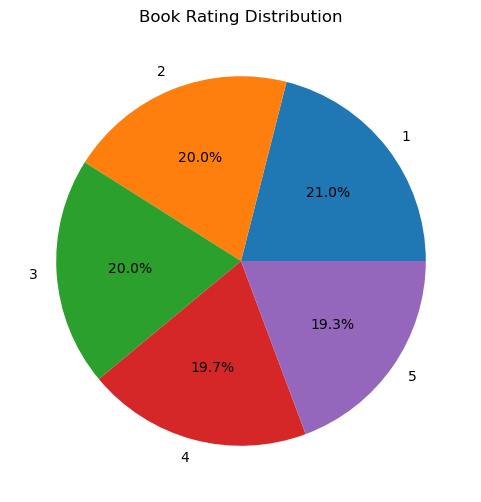

In [168]:
# Show the percentage of books by rating

rating_count = books_df["Rating"].value_counts().sort_index()

plt.figure(figsize=(6, 6))

plt.pie(
    rating_count,
    labels=rating_count.index,
    autopct="%1.1f%%"
)

plt.title("Book Rating Distribution")

plt.show()

In [169]:
# Create DataFrame from the scraped book data

books_df = pd.DataFrame(empty_list)

print("Dataset shape:", books_df.shape)

books_df.head()

Dataset shape: (580, 5)


,title,rating_tag,price_tag,availible_tag,category
0,A Light in the ...,Three,Â£51.77,In stock,N/A
1,Tipping the Velvet,One,Â£53.74,In stock,N/A
2,Soumission,One,Â£50.10,In stock,N/A
3,Sharp Objects,Four,Â£47.82,In stock,N/A
4,Sapiens: A Brief History ...,Five,Â£54.23,In stock,N/A


In [170]:
books_df = pd.DataFrame(empty_list)

In [171]:
books_df 

,title,rating_tag,price_tag,availible_tag,category
0,A Light in the ...,Three,Â£51.77,In stock,N/A
1,Tipping the Velvet,One,Â£53.74,In stock,N/A
2,Soumission,One,Â£50.10,In stock,N/A
3,Sharp Objects,Four,Â£47.82,In stock,N/A
4,Sapiens: A Brief History ...,Five,Â£54.23,In stock,N/A
...,...,...,...,...,...
575,"Death Note, Vol. 6: ...",Three,Â£36.39,In stock,N/A
576,Catherine the Great: Portrait ...,Four,Â£58.55,In stock,N/A
577,Better Homes and Gardens ...,Three,Â£39.61,In stock,N/A
578,An Unquiet Mind: A ...,Three,Â£21.30,In stock,N/A


In [172]:
# Display the final project completion message

print("Books data analysis project completed successfully.")
print("Data was scraped, cleaned, transformed, analyzed, and visualized.")
print("The project helped identify patterns in book price, rating, stock, and category.")

Books data analysis project completed successfully.
Data was scraped, cleaned, transformed, analyzed, and visualized.
The project helped identify patterns in book price, rating, stock, and category.


# Books Scraped: Key Insights:
Most books are priced within a similar range, showing that the website has many moderately priced books.

Books with higher ratings are not always more expensive. A good rating does not necessarily mean a higher price.

The dataset contains books with different rating levels, with some ratings appearing much more frequently than others.

Book prices show variation across the dataset, with some books being considerably more expensive than others.

The number of books differs across categories, meaning some categories are more common on the website than others.

Availability is mostly similar across the collected books, as many books are listed as available.

Price and rating have a weak relationship, suggesting that price alone does not determine how highly a book is rated.

Some categories have higher average prices than others, indicating differences in pricing between book categories.

The price distribution helps identify the common price range and also highlights relatively expensive books.

Overall, book rating, price, category, and availability do not strongly depend on one another, so customers can find highly rated books at different price levels.